<!-- CURRICULUM_HEADER_START -->
<div class="mh"><p class="mh-crumb"><a href="/series/forecasting/index.html">Forecasting with Machine Learning</a><span class="sep">·</span>Part 6 · Forecasting distributions</p><p class="mh-facts"><span class="lvl lvl-advanced">Advanced</span></p><p class="mh-assumes">Assumes <a href="/blogs/darts-direct-vs-recursive.html">Direct vs recursive in Darts</a> and <span class="unwritten" title="not written yet">Compositional data</span>.</p></div>
<!-- CURRICULUM_HEADER_END -->

::: {.callout-note appearance="simple" icon=false}
## TL;DR

A size distribution is a vector of proportions that must sum to one, and no regression model enforces that on its own. This module forecasts six fruit size buckets eight weeks ahead with a Darts `RandomForestModel`: the buckets become one multivariate `TimeSeries`, past-only and future-known covariates are kept apart, and each predicted row is renormalised back onto the simplex. You leave able to set up direct multi-step forecasting for any compositional target and knowing which settings to revisit on real data.
:::

Predicting how a population distributes across size buckets is a deceptively structured problem. The output is not a single number but a vector of proportions that must sum to one. When that output also spans an eight-week horizon, depends on agronomic covariates known only in the past, and arrives as weekly snapshots from a warehouse, single-output regression starts to show its seams.

The setup here tracks the weekly share of fruit across six size buckets, each expressed as a percentage of total volume, and forecasts how that distribution shifts over the following eight weeks. The covariates are accumulated growing degree days, fruit load per bush, temperature forecasts and planned irrigation. The previous approach wrapped a scikit-learn estimator in `MultiOutputRegressor`. It worked, but it was brittle around the multi-step horizon and needed manual scaffolding for covariates.

Darts handles this more naturally. It treats the six buckets as a single multivariate `TimeSeries`, supports past and future covariates as first-class inputs, and offers regression models that forecast several steps directly through `output_chunk_length`. The migration from an sklearn-style workflow is short, and the post-prediction normalisation step — needed because no regression model enforces the simplex constraint natively — carries over unchanged.

## Why Darts fits this problem

The library's `RandomForest` and `XGBModel` wrap tree-based estimators but expose a time-aware interface. You specify how many lags of the target and covariates the model should use as features, and you set `output_chunk_length` to the number of steps to predict directly. For an eight-week horizon, `output_chunk_length=8` tells the model to emit all eight future steps in a single forward pass rather than feeding predictions back as inputs recursively. Direct multi-step forecasting tends to be more accurate at longer horizons because errors do not compound.

The covariate split matters here. Growing degree days and fruit load are past-only: observed up to the forecast origin but not known beyond it. Temperature forecasts and planned irrigation are future-known: a weather service provides a week-8 outlook and the irrigation schedule is fixed in advance. Darts separates these into `past_covariates` and `future_covariates` arguments, so the model can use them appropriately without any manual feature-lagging logic in the calling code.

## The code

The example below uses two years of mock weekly data to demonstrate the full pipeline: constructing the `TimeSeries` objects, fitting the model, generating forecasts, and normalising the output back onto the simplex.

In [12]:
import pandas as pd
import numpy as np
from darts import TimeSeries
from darts.models import RandomForestModel
from darts.utils.timeseries_generation import datetime_attribute_timeseries
import warnings

warnings.filterwarnings("ignore")

np.random.seed(42)

In [13]:
# ====================== 1. Mock Weekly Time Series Data ======================
dates = pd.date_range(start="2023-01-01", periods=104, freq="W-MON")
n_weeks = len(dates)

gdd = np.random.uniform(800, 1200, n_weeks)
fruit_load = np.random.uniform(50, 200, n_weeks)
temp_forecast = np.random.uniform(20, 30, n_weeks)
irrigation_planned = np.random.uniform(10, 50, n_weeks)

base = np.random.dirichlet(alpha=[5, 8, 12, 10, 6, 3], size=n_weeks)
large_boost = 0.12 * ((gdd - 1000) / 200) + 0.10 * ((irrigation_planned - 30) / 20)
large_boost = np.clip(large_boost, -0.12, 0.18)

targets_raw = np.column_stack(
    [
        base[:, 0] * (1 - large_boost),
        base[:, 1] * (1 - 0.6 * large_boost),
        base[:, 2],
        base[:, 3] * (1 + 0.4 * large_boost),
        base[:, 4] * (1 + large_boost),
        base[:, 5] * (1 + 1.5 * large_boost),
    ]
)
targets = targets_raw / targets_raw.sum(axis=1, keepdims=True)

df = pd.DataFrame(
    {
        "date": dates,
        "gdd_accumulated": gdd,
        "fruit_load_per_bush": fruit_load,
        "temp_forecast_w8": temp_forecast,
        "irrigation_planned": irrigation_planned,
        "b_below_16": targets[:, 0],
        "b_16_18": targets[:, 1],
        "b_18_20": targets[:, 2],
        "b_20_22": targets[:, 3],
        "b_22_24": targets[:, 4],
        "b_24_plus": targets[:, 5],
    }
)

df.head()

,date,gdd_accumulated,fruit_load_per_bush,temp_forecast_w8,irrigation_planned,b_below_16,b_16_18,b_18_20,b_20_22,b_22_24,b_24_plus
0,2023-01-02,949.816048,186.134971,20.050616,11.014030,0.078901,0.128104,0.348841,0.280221,0.128889,0.035044
1,2023-01-09,1180.285723,87.393834,21.608081,48.505937,0.066508,0.158905,0.237435,0.292853,0.142523,0.101776
2,2023-01-16,1092.797577,111.557438,25.487338,43.439205,0.052332,0.111082,0.256106,0.258307,0.244123,0.078050
3,2023-01-23,1039.463394,163.332671,26.918952,37.838968,0.106472,0.162923,0.314417,0.184172,0.141245,0.090771
4,2023-01-30,862.407456,84.319725,26.519613,26.358118,0.115991,0.166535,0.239603,0.221111,0.229072,0.027687


In [14]:
# ====================== 2. Target TimeSeries ======================
target_series = TimeSeries.from_dataframe(
    df,
    time_col="date",
    value_cols=["b_below_16", "b_16_18", "b_18_20", "b_20_22", "b_22_24", "b_24_plus"],
)

# ====================== 3. Covariates ======================
past_cov = TimeSeries.from_dataframe(
    df,
    time_col="date",
    value_cols=["gdd_accumulated", "fruit_load_per_bush"],
)

future_cov = TimeSeries.from_dataframe(
    df,
    time_col="date",
    value_cols=["temp_forecast_w8", "irrigation_planned"],
)

time_cov = datetime_attribute_timeseries(target_series, attribute="weekofyear")
future_cov = future_cov.stack(time_cov)

split_point = len(target_series) - 8
train_target, test_target = target_series.split_after(split_point - 1)
train_past_cov, test_past_cov = past_cov.split_after(split_point - 1)
train_future_cov, test_future_cov = future_cov.split_after(split_point - 1)

In [17]:
# ====================== 4. Model ======================
model = RandomForestModel(
    lags=12,
    lags_past_covariates=12,
    lags_future_covariates=(0, 8),
    output_chunk_length=8,
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)

model.fit(
    series=train_target,
    past_covariates=past_cov,
    future_covariates=future_cov,
)

RandomForestModel(lags=12, lags_past_covariates=12, lags_future_covariates=(0, 8), output_chunk_length=8, output_chunk_shift=0, add_encoders=None, n_estimators=200, max_depth=None, multi_models=True, use_static_covariates=True, random_state=42, n_jobs=-1)

In [19]:
# ====================== 5. Prediction with Normalization ======================
def predict_size_distribution_darts(
    model, target_series, past_cov, future_cov, horizon=8
):
    raw_pred = model.predict(
        n=horizon,
        series=target_series,
        past_covariates=past_cov,
        future_covariates=future_cov,
    )
    pred_values = raw_pred.values()
    pred_values = np.maximum(pred_values, 0)
    row_sums = pred_values.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    normalized = pred_values / row_sums
    normalized_ts = TimeSeries.from_times_and_values(
        raw_pred.time_index, normalized, columns=target_series.components
    )
    return normalized_ts


pred_dist = predict_size_distribution_darts(
    model, train_target, past_cov, future_cov, horizon=8
)

print("Predicted Size Distribution (next 8 weeks):")
print(pred_dist.to_dataframe().round(4))
print("\nRow sums (should be ~1.0):")
print(pred_dist.values().sum(axis=1).round(4))

Predicted Size Distribution (next 8 weeks):
            b_below_16  b_16_18  b_18_20  b_20_22  b_22_24  b_24_plus
date                                                                 
2024-11-04      0.1142   0.1794   0.2733   0.2266   0.1270     0.0795
2024-11-11      0.1142   0.1788   0.2870   0.2164   0.1313     0.0723
2024-11-18      0.1167   0.1879   0.2757   0.2265   0.1212     0.0721
2024-11-25      0.1135   0.1849   0.2766   0.2300   0.1260     0.0691
2024-12-02      0.1141   0.1753   0.2798   0.2260   0.1291     0.0757
2024-12-09      0.1144   0.1731   0.2691   0.2411   0.1293     0.0730
2024-12-16      0.1141   0.1736   0.2772   0.2208   0.1379     0.0763
2024-12-23      0.1136   0.1716   0.2679   0.2326   0.1394     0.0750

Row sums (should be ~1.0):
[1. 1. 1. 1. 1. 1. 1. 1.]


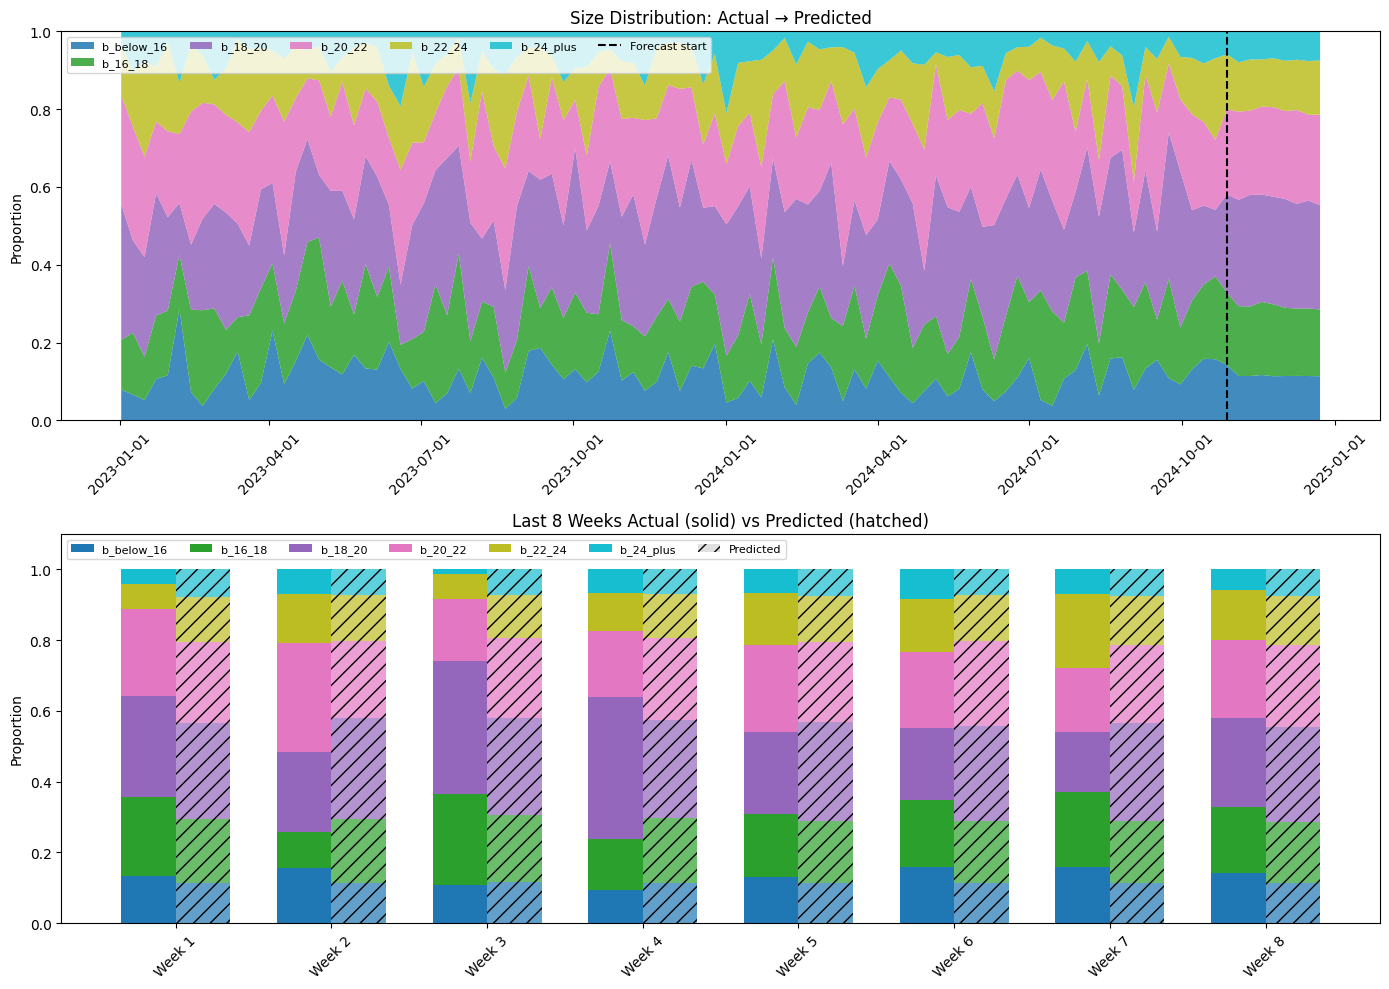

In [21]:
# ====================== 6. Visualization ======================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch

actual_df = train_target.to_dataframe()
pred_df = pred_dist.to_dataframe()
combined_df = pd.concat([actual_df, pred_df])
split_date = actual_df.index[-1]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
colors = plt.cm.tab10(np.linspace(0, 1, len(combined_df.columns)))

# Panel 1: Continuous stacked area
axes[0].stackplot(
    combined_df.index,
    *[combined_df[col] for col in combined_df.columns],
    labels=combined_df.columns,
    colors=colors,
    alpha=0.85,
)
axes[0].axvline(
    x=split_date, color="black", linestyle="--", linewidth=1.5, label="Forecast start"
)
axes[0].set_ylabel("Proportion")
axes[0].set_title("Size Distribution: Actual \u2192 Predicted")
axes[0].legend(loc="upper left", fontsize=8, ncol=len(combined_df.columns))
axes[0].set_ylim(0, 1)

# Panel 2: Side-by-side comparison
last_actual_df = actual_df.iloc[-8:]
comparison_weeks = range(1, 9)
bar_width = 0.35
x = np.arange(len(comparison_weeks))
bottom_actual = np.zeros(len(comparison_weeks))
bottom_pred = np.zeros(len(comparison_weeks))

for i, col in enumerate(combined_df.columns):
    axes[1].bar(
        x - bar_width / 2,
        last_actual_df[col].values,
        bar_width,
        bottom=bottom_actual,
        color=colors[i],
        alpha=1,
    )
    axes[1].bar(
        x + bar_width / 2,
        pred_df[col].values,
        bar_width,
        bottom=bottom_pred,
        color=colors[i],
        alpha=0.7,
        hatch="//",
    )
    bottom_actual += last_actual_df[col].values
    bottom_pred += pred_df[col].values

axes[1].set_xticks(x)
axes[1].set_xticklabels([f"Week {w}" for w in comparison_weeks])
axes[1].set_ylabel("Proportion")
axes[1].set_title("Last 8 Weeks Actual (solid) vs Predicted (hatched)")
axes[1].set_ylim(0, 1.1)

legend_elements = [
    Patch(facecolor=colors[i], alpha=1, label=col)
    for i, col in enumerate(combined_df.columns)
]
legend_elements += [
    Patch(facecolor="lightgray", alpha=0.7, hatch="//", label="Predicted")
]
axes[1].legend(
    handles=legend_elements,
    loc="upper left",
    fontsize=8,
    ncol=len(combined_df.columns) + 1,
)

for ax in axes:
    if ax == axes[0]:
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Three details in the implementation are worth noting. The `lags_future_covariates=(0, 8)` argument tells the model to include the current value and the next eight steps of the future covariates as features, which aligns with the forecast horizon. Week-of-year is appended to the covariate series via `datetime_attribute_timeseries`, giving the model a seasonal signal without explicit calendar feature engineering. The normalisation step clips negative predictions to zero before rescaling, which prevents any bucket from contributing negative probability mass while preserving the relative magnitudes.

## Adapting this to real data

When moving from mock to production data, three decisions need to be made explicitly. First, classify each covariate as past-only or future-known and pass it to the correct argument. Passing a past-only covariate as `future_covariates` will cause the model to expect values it cannot have at inference time. Second, the lag length of 12 weeks is a starting point: if the crop cycle has a longer memory — for instance, if GDD from three months ago still influences current size distribution — extending the lags is worth testing. Third, `output_chunk_length` should match the operational horizon; if the business needs both a four-week and an eight-week view, training two separate models with different chunk lengths is cleaner than slicing a longer forecast.

For evaluation, per-bucket MAE is a useful first metric but does not capture whether the predicted distribution is well-shaped. The Kullback-Leibler divergence or the Wasserstein distance between the predicted and actual distributions gives a more meaningful signal when the shape of the distribution matters as much as the individual bucket values.

### When to upgrade the model

`RandomForest` is a reasonable baseline with low tuning overhead. If the error profile shows systematic bias at longer horizons, `XGBModel` tends to generalise better with gradient boosting. If two or more years of weekly data are available and the seasonal patterns are pronounced, `TFTModel` (Temporal Fusion Transformer) handles long-range dependencies and variable-selection attention in a way that tree models cannot, at the cost of longer training time and more hyperparameters to manage.

Whichever model is used, wrapping the training and forecasting steps in `historical_forecasts()` gives an honest backtest: the library simulates the walk-forward evaluation automatically, producing a forecast series that can be compared directly against the held-out actuals without data leakage.

## Key takeaways

- Treat the buckets as one multivariate `TimeSeries`; the model then sees the whole distribution at every lag instead of six unrelated targets.
- `output_chunk_length=8` produces all eight weeks in one pass, so errors do not compound the way they do in a recursive forecast.
- Classify every covariate as past-only or future-known before writing code; a past-only series passed as `future_covariates` demands values that will not exist at inference time.
- No regressor enforces the simplex: clip negatives to zero and divide each row by its sum after predicting, then check the row sums.
- Score with per-bucket MAE first, then KL divergence or Wasserstein distance when the shape matters, and backtest with `historical_forecasts()`.

<!-- CURRICULUM_FOOTER_START -->
<div class="mf"><a class="mf-prev" href="/blogs/darts-direct-vs-recursive.html"><span>Previous</span>Direct vs recursive in Darts</a><a class="mf-up" href="/series/forecasting/index.html"><span>Series</span>Forecasting with Machine Learning</a><a class="mf-next" href="/blogs/lightgbm-cross-entropy-bounded-target.html"><span>Next</span>Cross-entropy for bounded targets</a></div>
<!-- CURRICULUM_FOOTER_END -->